# Noise-aware training for 2D classification with physical SYNE-KANs

This notebook compares standard training, relative-noise-aware training, and relative+additive-noise-aware training on the two released 2D classification tasks.

Evaluation spans a two-dimensional relative×additive control-noise grid and the three requested physical sampling cases, always ordered as:

1. static drift + read noise;
2. read noise only;
3. static drift only.

The paper profile uses 800 training epochs, noise levels up to 100%, and 32 evaluation draws. The quick profile runs the same workflow at reduced cost.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
import time
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")


def seed_everything(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def stable_seed(*parts) -> int:
    """Build a repeatable integer seed from a readable run description."""
    raw = "|".join(map(str, parts)).encode("utf-8")
    return int(hashlib.sha256(raw).hexdigest()[:8], 16)


print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 1.13.1


## Run configuration

The tasks, architectures, data split and digital twin are unchanged. Relative noise is multiplicative. Additive noise is independent of control magnitude and normalised to the measured 0.151 V RMS range across the trained SYNE-KAN control voltages. The relative-only and relative+additive presets are the deployed winners in the supplied jack_protocol workflow.


In [2]:
# -----------------------------------------------------------------------------
# USER SETTINGS
# -----------------------------------------------------------------------------
RUN_PROFILE = "paper"       # "quick" or "paper"

TWIN_PATH = Path(
    os.environ.get("SYNE_TWIN_PATH", Path.cwd() / "SYNE_device_digital_twin.pt")
).expanduser()
OUTPUT_ROOT = Path(
    os.environ.get(
        "SYNE_RESULTS_DIR",
        f"results_2d_classification_noise_aware_{RUN_PROFILE}",
    )
).expanduser()

TASKS = ["checker_5x5", "yin_yang"]
TASK_LABELS = {
    "checker_5x5": "5×5 checkerboard",
    "yin_yang": "Five-circle yin–yang",
}
TASK_ARCHITECTURES = {
    "checker_5x5": [2, 6, 1],
    "yin_yang": [2, 2, 1],
}
DEVICES_PER_EDGE = 8
N_INPUTS = 2
DEVELOPMENT_POINTS = 8000
TEST_POINTS = 10000
VALIDATION_FRACTION = 0.10
SPLIT_SEED = 404

AMPLITUDE_POWER = 1.0
WARMUP_FRACTION = 0.30
READ_NOISE_PROB = 0.5
JOINT_PROB = 0.5

WINNERS = {
    "checker_5x5": {
        "relative": dict(max_amp=0.60, max_abs=0.0, clean_weight=0.2, run_index=2),
        "hybrid": dict(max_amp=0.60, max_abs=0.10, clean_weight=0.2, run_index=1),
    },
    "yin_yang": {
        "relative": dict(max_amp=0.40, max_abs=0.0, clean_weight=0.2, run_index=3),
        "hybrid": dict(max_amp=0.40, max_abs=0.40, clean_weight=0.2, run_index=3),
    },
}
TRAINING_ORDER = (
    "hybrid_noise_aware",
    "relative_noise_aware",
    "standard",
)
TRAINING_LABELS = {
    "hybrid_noise_aware": "Noise-aware training with relative and additive noise",
    "relative_noise_aware": "Noise-aware training with relative noise only",
    "standard": "Standard training with no noise-aware training",
}
EVALUATION_MODES = (
    "static_plus_read",
    "read_noise",
    "static_drift",
)
MODE_LABELS = {
    "static_plus_read": "Static drift + read noise",
    "read_noise": "Read noise only",
    "static_drift": "Static drift only",
}

# Measured RMS range across the trained SYNE-KAN tuning voltages.
# This defines 100% additive noise throughout training and evaluation.
ADDITIVE_FULL_RANGE_V = 0.151
ROBUST_LEVELS = (0.05, 0.10, 0.20, 0.50)
HYBRID_ROBUST_PROBES = (
    (0.10, 0.0), (0.20, 0.0), (0.50, 0.0),
    (0.0, 0.02), (0.0, 0.05), (0.0, 0.10),
    (0.20, 0.05), (0.50, 0.10),
)
ROBUST_DRAWS = 3
ROBUST_CLEAN_WEIGHT = 1.0
ROBUST_SEED_BASE = 777_000
PREDICT_CHUNK = 2048
LOSS_FLOOR = 1e-12
EVAL_NOISE_SEED = 1234

PROFILES = {
    "quick": {
        "max_epochs": 120,
        "relative_levels_percent": (0.0, 2.0, 10.0, 50.0, 100.0),
        "additive_levels_percent": (0.0, 2.0, 10.0, 50.0, 100.0),
        "eval_draws": 5,
    },
    "paper": {
        "max_epochs": 800,
        "relative_levels_percent": (
            0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0
        ),
        "additive_levels_percent": (
            0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0
        ),
        "eval_draws": 32,
    },
}
if RUN_PROFILE not in PROFILES:
    raise ValueError(f"RUN_PROFILE must be one of {list(PROFILES)}")
PROFILE = PROFILES[RUN_PROFILE]
MAX_EPOCHS = int(PROFILE["max_epochs"])
RELATIVE_LEVELS_PERCENT = tuple(PROFILE["relative_levels_percent"])
ADDITIVE_LEVELS_PERCENT = tuple(PROFILE["additive_levels_percent"])
EVAL_DRAWS = int(PROFILE["eval_draws"])
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Run profile:", RUN_PROFILE)
print("Twin checkpoint:", TWIN_PATH)
print("Results folder:", OUTPUT_ROOT)
print("Tasks:", TASKS)
print("Training winners:", WINNERS)
print("Evaluation modes:", EVALUATION_MODES)
print("Relative levels (%):", RELATIVE_LEVELS_PERCENT)
print("Additive levels (% of 0.151 V RMS range):", ADDITIVE_LEVELS_PERCENT)
print("Evaluation draws:", EVAL_DRAWS)


Run profile: paper
Twin checkpoint: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\SYNE_device_digital_twin.pt
Results folder: results_2d_classification_noise_aware_paper
Tasks: ['checker_5x5', 'yin_yang']
Training winners: {'checker_5x5': {'relative': {'max_amp': 0.6, 'max_abs': 0.0, 'clean_weight': 0.2, 'run_index': 2}, 'hybrid': {'max_amp': 0.6, 'max_abs': 0.1, 'clean_weight': 0.2, 'run_index': 1}}, 'yin_yang': {'relative': {'max_amp': 0.4, 'max_abs': 0.0, 'clean_weight': 0.2, 'run_index': 3}, 'hybrid': {'max_amp': 0.4, 'max_abs': 0.4, 'clean_weight': 0.2, 'run_index': 3}}}
Evaluation modes: ('static_plus_read', 'read_noise', 'static_drift')
Relative levels (%): (0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0)
Additive levels (% of 0.151 V RMS range): (0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0)
Evaluation draws: 32


## Classification tasks and data protocol

The checkerboard is formed directly on $[-1,1]^2$ by alternating binary class labels over a $5\times5$ square grid. The yin–yang target is formed from a set of circles. For each task 8,000 points are sampled and split into training and validation; a separate 10,000-point test set is generated from an independent seed.

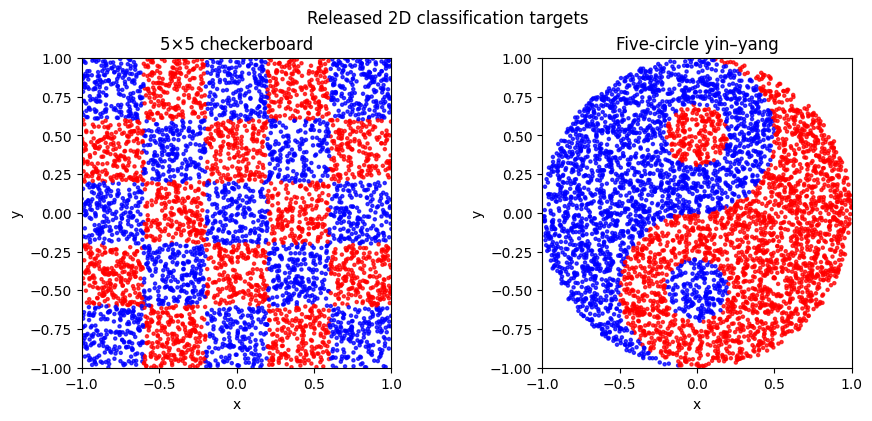

In [3]:
def sample_unit_disk(rng, number_of_points):
    radius = np.sqrt(rng.random(number_of_points))
    angle = rng.uniform(0.0, 2.0 * np.pi, number_of_points)
    return np.column_stack(
        [radius * np.cos(angle), radius * np.sin(angle)]
    ).astype(np.float32)


def yin_yang_labels(points):
    x, y = points[:, 0], points[:, 1]

    in_top_circle = x**2 + (y - 0.5) ** 2 <= 0.5**2
    in_bottom_circle = x**2 + (y + 0.5) ** 2 <= 0.5**2
    in_top_dot = x**2 + (y - 0.5) ** 2 <= 0.2**2
    in_bottom_dot = x**2 + (y + 0.5) ** 2 <= 0.2**2

    labels = np.zeros(len(points), dtype=np.float32)
    labels[in_bottom_circle] = 1.0

    side_region = ~in_top_circle & ~in_bottom_circle
    labels[side_region & (x >= 0.0)] = 1.0

    # The two small dots reverse the colour of the surrounding lobe.
    labels[in_top_dot] = 1.0
    labels[in_bottom_dot] = 0.0
    return labels


def generate_task(task_name, seed, number_of_points):
    rng = np.random.default_rng(seed)

    if task_name == "checker_5x5":
        points = rng.uniform(
            -1.0, 1.0, (number_of_points, 2)
        ).astype(np.float32)
        square = np.floor((points + 1.0) * 2.5).astype(int).clip(0, 4)
        labels = ((square[:, 0] + square[:, 1]) % 2).astype(np.float32)
        return points, labels

    if task_name == "yin_yang":
        points = sample_unit_disk(rng, number_of_points)
        return points, yin_yang_labels(points)

    raise KeyError(f"Unknown classification task: {task_name}")


def stratified_train_validation_indices(
    x,
    y,
    seed,
    validation_fraction=VALIDATION_FRACTION,
):
    del x  # retained in the signature to make the split call self-documenting
    rng = np.random.default_rng(seed)
    training_indices, validation_indices = [], []

    for class_label in (0, 1):
        indices = np.flatnonzero(y == class_label)
        rng.shuffle(indices)
        number_validation = int(round(validation_fraction * len(indices)))
        validation_indices.extend(indices[:number_validation])
        training_indices.extend(indices[number_validation:])

    rng.shuffle(training_indices)
    rng.shuffle(validation_indices)
    return np.asarray(training_indices), np.asarray(validation_indices)


def make_split(task_name, seed):
    development_x, development_y = generate_task(
        task_name,
        stable_seed("development_pool", task_name, seed),
        DEVELOPMENT_POINTS,
    )
    test_x, test_y = generate_task(
        task_name,
        stable_seed("held_out_test", task_name, seed),
        TEST_POINTS,
    )

    training_indices, validation_indices = (
        stratified_train_validation_indices(
            development_x,
            development_y,
            seed,
        )
    )

    return {
        "x_train": torch.from_numpy(development_x[training_indices]),
        "y_train": torch.from_numpy(development_y[training_indices, None]),
        "x_val": torch.from_numpy(development_x[validation_indices]),
        "y_val": torch.from_numpy(development_y[validation_indices, None]),
        "x_test": torch.from_numpy(test_x),
        "y_test": torch.from_numpy(test_y[:, None]),
    }


fig, axes = plt.subplots(
    1, 2, figsize=(9.2, 4.1), constrained_layout=True
)
for axis, task_name in zip(axes, TASKS):
    points, labels = generate_task(
        task_name,
        stable_seed("preview", task_name),
        5000,
    )
    axis.scatter(
        points[:, 0],
        points[:, 1],
        c=labels,
        cmap="bwr",
        s=5,
        alpha=0.75,
    )
    axis.set_title(TASK_LABELS[task_name])
    axis.set_xlim(-1, 1)
    axis.set_ylim(-1, 1)
    axis.set_aspect("equal")
    axis.set_xlabel("x")
    axis.set_ylabel("y")

fig.suptitle("Released 2D classification targets")
plt.show()

## SYNE device digital twin + SYNE-KAN

The loader accepts a saved `nn.Module` or a compatible MLP state dictionary. The twin is converted to float32, placed in evaluation mode and frozen, and the SYNE-KAN is built on multiple copies of it.

In [4]:
class RebuiltTwin(nn.Module):
    """Fallback for a checkpoint containing only an ordinary MLP state_dict."""
    def __init__(self, weights, biases):
        super().__init__()
        self.weights = nn.ParameterList([nn.Parameter(w.clone(), requires_grad=False) for w in weights])
        self.biases = nn.ParameterList([nn.Parameter(b.clone(), requires_grad=False) for b in biases])

    def forward(self, x):
        for i, (weight, bias) in enumerate(zip(self.weights, self.biases)):
            x = F.linear(x, weight, bias)
            if i + 1 < len(self.weights):
                x = F.relu(x)
        return x

def _natural_key(name: str):
    import re
    return [int(p) if p.isdigit() else p for p in re.split(r"(\d+)", name)]

def _strip_prefix(text: str, prefix: str) -> str:
    """Python 3.8-compatible replacement for str.removeprefix()."""
    return text[len(prefix):] if text.startswith(prefix) else text

def load_frozen_twin(path: Path) -> nn.Module:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Digital twin not found: {path}\n"
            "Set TWIN_PATH in the configuration cell. The expected checkpoint is either "
            "a saved nn.Module, [module, x_scale, y_scale], or an MLP state_dict."
        )
    try:
        payload = torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        # Compatibility with PyTorch versions predating `weights_only`.
        payload = torch.load(path, map_location=DEVICE)
    if isinstance(payload, nn.Module):
        twin = payload
    elif isinstance(payload, (list, tuple)) and payload and isinstance(payload[0], nn.Module):
        twin = payload[0]
    else:
        state = payload.get("model_state_dict", payload.get("state_dict", payload)) if isinstance(payload, dict) else None
        if not isinstance(state, dict):
            raise TypeError(f"Unsupported twin checkpoint payload: {type(payload)}")
        cleaned_state = {}
        for key, value in state.items():
            key = _strip_prefix(str(key), "module.")
            key = _strip_prefix(key, "model.")
            cleaned_state[key] = value
        state = cleaned_state
        weight_keys = sorted([k for k, v in state.items() if k.endswith("weight") and getattr(v, "ndim", 0) == 2], key=_natural_key)
        if not weight_keys:
            raise ValueError("No linear weights found in the twin state_dict")
        weights, biases = [], []
        for key in weight_keys:
            weights.append(state[key].float())
            bias_key = key[:-6] + "bias"
            biases.append(state.get(bias_key, torch.zeros(state[key].shape[0])).float())
        twin = RebuiltTwin(weights, biases)

    twin = twin.to(DEVICE).float().eval()
    for parameter in twin.parameters():
        parameter.requires_grad_(False)
    print("Loaded and froze twin:", path, "|", type(twin).__name__)
    return twin


class PhysicalKAN(nn.Module):
    """Constant-control physical SYNE-KAN used across the release notebooks."""
    def __init__(self, twin, architecture, devices_per_edge, hp):
        super().__init__()
        self.twin = twin
        self.architecture = list(map(int, architecture))
        self.devices_per_edge = int(devices_per_edge)
        self.hp = dict(hp)
        self.controls_per_device = 2
        self.squash_gain = 6.0
        self.output_gain_scale = float(hp["output_gain_scale"])
        self.twin_microbatch = int(hp.get("twin_microbatch", 262144))
        for p in self.twin.parameters():
            p.requires_grad_(False)

        self.S_min, self.S_max = nn.ParameterList(), nn.ParameterList()
        self.V, self.G_o = nn.ParameterList(), nn.ParameterList()
        self.B_o = nn.ParameterList()
        for n_in, n_out in zip(self.architecture[:-1], self.architecture[1:]):
            shape = (n_in, n_out, self.devices_per_edge)
            self.S_min.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.S_max.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.V.append(nn.Parameter(torch.zeros(*shape, 2, device=DEVICE)))
            self.G_o.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.B_o.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
        self._initialise()

    def train(self, mode=True):
        super().train(mode)
        self.twin.eval()
        return self

    def squash_signal(self, raw):
        return 2.0 * torch.sigmoid(self.squash_gain * raw) - 1.0

    @staticmethod
    def squash_control(raw):
        return 2.0 * torch.sigmoid(raw) - 1.0

    def inverse_signal(self, value):
        p = ((value + 1.0) * 0.5).clamp(1e-6, 1.0 - 1e-6)
        return torch.log(p / (1.0 - p)) / self.squash_gain

    def _initialise(self):
        with torch.no_grad():
            for layer, (n_in, n_out) in enumerate(zip(self.architecture[:-1], self.architecture[1:])):
                shape = (n_in, n_out, self.devices_per_edge)
                count = int(np.prod(shape))
                dv_min = float(self.hp["init_dv_min"])
                dv_max = min(float(self.hp["init_dv_max"]), 1.96)
                widths = torch.linspace(dv_min, dv_max, count, device=DEVICE)
                step = (dv_max - dv_min) / max(count - 1, 1)
                widths += (torch.rand(count, device=DEVICE) - 0.5) * 2 * step * float(self.hp["span_jitter"])
                widths = widths.clamp(dv_min, dv_max)[torch.randperm(count, device=DEVICE)].reshape(shape)
                fan = float(n_in * self.devices_per_edge)
                if self.hp["init_style"] == "powerlaw":
                    widths = dv_min + (widths - dv_min) * max(0.1, min(1.0, fan ** (-float(self.hp["pl_beta"]))))
                inverted = torch.rand(shape, device=DEVICE) < float(self.hp["invert_probability"])
                low, high = -0.98 + 0.5 * widths, 0.98 - 0.5 * widths
                centre = low + torch.rand(shape, device=DEVICE) * (high - low)
                centre = torch.where(inverted, torch.zeros_like(centre), centre)
                vmin, vmax = centre - 0.5 * widths, centre + 0.5 * widths
                lo = torch.where(inverted, vmax, vmin)
                hi = torch.where(inverted, vmin, vmax)
                self.S_min[layer].copy_(self.inverse_signal(lo.clamp(-0.98, 0.98)))
                self.S_max[layer].copy_(self.inverse_signal(hi.clamp(-0.98, 0.98)))

                shrink = fan ** (-float(self.hp["pl_alpha"])) if self.hp["init_style"] == "powerlaw" else 1.0
                limit = math.sqrt(6.0 / 4.0) * float(self.hp["control_init_scale"]) * shrink
                # No lower/upper control-voltage initialisation limit. The raw
                # parameters are sampled symmetrically, then mapped to the
                # normalised physical voltage by squash_control() in forward().
                self.V[layer].uniform_(-limit, limit)
                self.G_o[layer].zero_()
                self.B_o[layer].zero_()

    def _twin_forward(self, flat):
        return torch.cat([self.twin(flat[i:i+self.twin_microbatch]).reshape(-1)
                          for i in range(0, len(flat), self.twin_microbatch)], dim=0)

    def forward(self, inputs):
        activation = inputs
        for layer, (n_in, n_out) in enumerate(zip(self.architecture[:-1], self.architecture[1:])):
            scalar = activation.unsqueeze(2).unsqueeze(3)
            pmin = self.squash_signal(self.S_min[layer])
            pmax = self.squash_signal(self.S_max[layer])
            signal = (0.5 * (pmax-pmin).unsqueeze(0) * scalar + 0.5 * (pmax+pmin).unsqueeze(0)).unsqueeze(-1)
            controls = self.squash_control(self.V[layer]).unsqueeze(0).expand(len(activation), -1, -1, -1, -1)
            twin_in = torch.cat([signal, controls], dim=-1)
            twin_out = self._twin_forward(twin_in.reshape(-1, 3)).reshape(
                len(activation), n_in, n_out, self.devices_per_edge)
            contribution = self.output_gain_scale * self.G_o[layer].unsqueeze(0) * twin_out
            contribution = contribution + self.B_o[layer].unsqueeze(0)
            activation = contribution.sum(dim=(1, 3))
        return activation

    def parameter_groups(self):
        ranges = list(self.S_min.parameters()) + list(self.S_max.parameters())
        controls = list(self.V.parameters())
        outputs = list(self.G_o.parameters()) + list(self.B_o.parameters())
        return [
            {"name": "gains_biases", "params": outputs, "lr": float(self.hp["lr_gobo"]), "weight_decay": 0.0},
            {"name": "controls", "params": controls, "lr": float(self.hp["lr_v"]), "weight_decay": 0.0},
            {"name": "ranges", "params": ranges, "lr": float(self.hp["lr_s"]), "weight_decay": 0.0},
        ]

    def actual_trainable_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def manuscript_parameter_count(self):
        edges = sum(a*b for a, b in zip(self.architecture[:-1], self.architecture[1:]))
        post_synaptic = sum(self.architecture[1:])
        return 5 * edges * self.devices_per_edge + post_synaptic

In [5]:
def compact_state(model):
    trainable = {name for name, p in model.named_parameters() if p.requires_grad}
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items() if k in trainable}

def restore_compact_state(model, state):
    current = model.state_dict()
    current.update({k: v.to(current[k].device) for k, v in state.items()})
    model.load_state_dict(current, strict=True)

def make_scheduler(optimizer, hp, max_epochs):
    if hp["scheduler"] == "cosine":
        minimum = float(hp["lr_min_frac"])
        def cosine_multiplier(epoch):
            progress = min(max(epoch, 0), max_epochs - 1) / float(max(max_epochs - 1, 1))
            return minimum + 0.5 * (1.0 - minimum) * (1.0 + math.cos(math.pi * progress))
        # LambdaLR multiplies every group's own base LR by the same factor,
        # preserving the NASA lr_gobo : lr_v : lr_s ratios throughout training.
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=cosine_multiplier)
    if hp["scheduler"] == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(20, max_epochs // 8), gamma=float(hp["step_gamma"]))
    return None

@torch.no_grad()
def predict(model, x, chunk=8192):
    model.eval()
    outs = []
    for i in range(0, len(x), chunk):
        outs.append(model(x[i:i+chunk].to(DEVICE)).detach().cpu())
    return torch.cat(outs)

KAN_RECIPE = {
    "batch_size": 64,
    "beta1": 0.8732514841987591,
    "beta2": 0.9319380888083301,
    "control_init_scale": 0.37017654055169313,
    "evaluate_every": 10,
    "grad_clip": 1.1216607973942743,
    "init_dv_min": 0.9217543569919135,
    "init_dv_max": 1.4779169762511962,
    "init_style": "powerlaw",
    "invert_probability": 0.17769176737480483,
    "lr_gobo": 0.004351773638989695,
    "lr_min_frac": 0.017159459089982974,
    "lr_s": 0.00043962166763540476,
    "lr_v": 9.058647273851198e-05,
    "min_delta": 1e-6,
    "minimum_epochs": 100,
    "output_gain_scale": 50.0,
    "patience_evaluations": 20,
    "pl_alpha": 1.2699093429385424,
    "pl_beta": 1.4623654755469275,
    "scheduler": "cosine",
    "span_jitter": 0.053076231040254655,
    "step_gamma": 0.8239896378821361,
    "adam_eps": 1e-8,
}

TWIN = load_frozen_twin(TWIN_PATH)


Loaded and froze twin: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\SYNE_device_digital_twin.pt | RebuiltTwin


## Control-voltage corruption

Only control voltages are corrupted:

$$
V'=\operatorname{clamp}\left[V(1+d_\mathrm{rel})+d_\mathrm{abs},-1,1\right].
$$

Relative noise has $\sigma_\mathrm{rel}=p_\mathrm{rel}|V|$. Additive noise has $\sigma_\mathrm{abs}=p_\mathrm{abs}\times0.151\,\mathrm{V}$, where 0.151 V is the measured RMS range across the trained SYNE-KAN tuning voltages and therefore defines 100% additive noise.

For static_plus_read, an independent per-control static field is frozen across the test set and summed with a fresh per-example read field. Each component receives the full stated amplitude, so its combined instantaneous RMS is $\sqrt{2}$ times the axis amplitude. read_noise uses only the fresh field; static_drift uses only the frozen field.


In [6]:
def sample_deltas(model, amplitude, kind, batch_size, device, generator=None):
    if kind not in ("static_drift", "read_noise"):
        raise KeyError(kind)
    deltas = []
    for layer_v in model.V:
        shape = tuple(layer_v.shape)
        delta_shape = shape if kind == "static_drift" else (int(batch_size),) + shape
        deltas.append(
            torch.randn(delta_shape, device=device, generator=generator) * amplitude
        )
    return deltas


def combine_deltas(first, second):
    """Sum static and per-example fields with explicit batch broadcasting."""
    if first is None:
        return second
    if second is None:
        return first
    combined = []
    for left, right in zip(first, second):
        if left.ndim + 1 == right.ndim:
            left = left.unsqueeze(0)
        elif right.ndim + 1 == left.ndim:
            right = right.unsqueeze(0)
        combined.append(left + right)
    return combined


def perturbed_forward(self, inputs):
    """Notebook forward with the control-voltage deltas spliced in."""
    activation = inputs
    for layer, (n_in, n_out) in enumerate(
        zip(self.architecture[:-1], self.architecture[1:])
    ):
        scalar = activation.unsqueeze(2).unsqueeze(3)
        pmin = self.squash_signal(self.S_min[layer])
        pmax = self.squash_signal(self.S_max[layer])
        signal = (
            0.5 * (pmax - pmin).unsqueeze(0) * scalar
            + 0.5 * (pmax + pmin).unsqueeze(0)
        ).unsqueeze(-1)
        clean = self.squash_control(self.V[layer])
        delta = (None if self.relative_control_deltas is None
                 else self.relative_control_deltas[layer])
        abs_delta = (None
                     if getattr(self, "absolute_control_deltas", None) is None
                     else self.absolute_control_deltas[layer])
        if delta is None and abs_delta is None:
            controls = clean.unsqueeze(0).expand(len(activation), -1, -1, -1, -1)
        else:
            perturbed = clean.unsqueeze(0)
            if delta is not None:
                d = delta if delta.ndim == clean.ndim + 1 else delta.unsqueeze(0)
                perturbed = perturbed * (1.0 + d)
            if abs_delta is not None:
                a = abs_delta if abs_delta.ndim == clean.ndim + 1 else abs_delta.unsqueeze(0)
                perturbed = perturbed + a
            self._saturated += int((perturbed.abs() > 1.0).sum())
            self._sat_total += perturbed.numel()
            perturbed = perturbed.clamp(-1.0, 1.0)
            if perturbed.shape[0] == 1 and len(activation) > 1:
                controls = perturbed.expand(len(activation), -1, -1, -1, -1)
            else:
                controls = perturbed
        twin_inputs = torch.cat([signal, controls], dim=-1)
        twin_outputs = self._twin_forward(twin_inputs.reshape(-1, 3)).reshape(
            len(activation), n_in, n_out, self.devices_per_edge
        )
        contribution = (
            self.output_gain_scale * self.G_o[layer].unsqueeze(0)
            * twin_outputs + self.B_o[layer].unsqueeze(0)
        )
        activation = contribution.sum(dim=(1, 3))
    return activation


def attach_perturbation(model):
    """Swap in the perturbed forward and reset the delta and saturation state."""
    model.relative_control_deltas = None
    model.absolute_control_deltas = None
    model._saturated = 0
    model._sat_total = 0
    model.forward = types.MethodType(perturbed_forward, model)
    return model


## Robust checkpoint selection

Relative-noise-aware checkpoints use clean validation BCE plus fixed-seed static-drift probes at 5/10/20/50% relative noise. Relative+additive checkpoints use the supplied 2D probe set: three relative-only points, three additive-only points and two simultaneous points. Standard checkpoints use clean validation BCE. The test set is never used for selection.


In [7]:
@torch.no_grad()
def robust_validation_score(model, split, hybrid):
    loss_fn = nn.BCEWithLogitsLoss()
    was_training = model.training
    model.eval()
    x_val = split["x_val"].to(DEVICE)
    y_val = split["y_val"].to(DEVICE)
    model.relative_control_deltas = None
    model.absolute_control_deltas = None
    clean = float(loss_fn(model(x_val).reshape_as(y_val), y_val).item())
    terms = [(max(clean, LOSS_FLOOR), ROBUST_CLEAN_WEIGHT)]
    generator = torch.Generator(device=DEVICE)
    probes = (
        HYBRID_ROBUST_PROBES
        if hybrid else tuple((level, 0.0) for level in ROBUST_LEVELS)
    )
    for level_index, (relative_level, additive_fraction) in enumerate(probes):
        losses = []
        for draw in range(ROBUST_DRAWS):
            generator.manual_seed(ROBUST_SEED_BASE + 1000 * level_index + draw)
            model.relative_control_deltas = (
                sample_deltas(
                    model, relative_level, "static_drift", 1, DEVICE, generator
                ) if relative_level > 0.0 else None
            )
            model.absolute_control_deltas = (
                sample_deltas(
                    model, additive_fraction * ADDITIVE_FULL_RANGE_V,
                    "static_drift", 1, DEVICE, generator
                ) if additive_fraction > 0.0 else None
            )
            losses.append(float(
                loss_fn(model(x_val).reshape_as(y_val), y_val).item()
            ))
        model.relative_control_deltas = None
        model.absolute_control_deltas = None
        mean_loss = max(sum(losses) / len(losses), LOSS_FLOOR)
        weight = math.sqrt(max(
            relative_level / max(ROBUST_LEVELS),
            additive_fraction / 0.10,
        ))
        terms.append((mean_loss, weight))
    total_weight = sum(weight for _, weight in terms)
    score = math.exp(
        sum(weight * math.log(value) for value, weight in terms) / total_weight
    )
    if was_training:
        model.train()
    return score


@torch.no_grad()
def clean_validation_bce(model, split):
    model.relative_control_deltas = None
    model.absolute_control_deltas = None
    prediction = predict(model, split["x_val"])
    return float(nn.BCEWithLogitsLoss()(
        prediction.reshape_as(split["y_val"]), split["y_val"]
    ).item())


## Noise-aware training

Both robust models use jack_noise randomised injection with
$L=cL_\mathrm{clean}+(1-c)L_\mathrm{corrupted}$.

Relative and additive amplitudes are independently sampled below cosine-warmed ceilings. The temporal corruption is static or read noise with equal probability. In hybrid training, half of corrupted batches contain both channels; the remainder is split evenly between relative-only and additive-only corruption.


In [8]:
def sample_training_corruption(
    model, batch_size, relative_ceiling, additive_ceiling
):
    relative_amplitude = (
        relative_ceiling * float(torch.rand(()).item()) ** AMPLITUDE_POWER
    )
    additive_fraction = 0.0
    kind = (
        "read_noise"
        if float(torch.rand(()).item()) < READ_NOISE_PROB
        else "static_drift"
    )
    if additive_ceiling > 0.0:
        additive_fraction = additive_ceiling * float(torch.rand(()).item())
        mixture = float(torch.rand(()).item())
        solo_probability = 0.5 * (1.0 - JOINT_PROB)
        if mixture < solo_probability:
            additive_fraction = 0.0
        elif mixture < 2.0 * solo_probability:
            relative_amplitude = 0.0
    relative_deltas = (
        sample_deltas(model, relative_amplitude, kind, batch_size, DEVICE)
        if relative_amplitude > 0.0 else None
    )
    additive_deltas = (
        sample_deltas(
            model, additive_fraction * ADDITIVE_FULL_RANGE_V,
            kind, batch_size, DEVICE
        )
        if additive_fraction > 0.0 else None
    )
    return relative_deltas, additive_deltas


def train(
    model, split, hp, run_seed, training_configuration,
    max_amp, max_abs, clean_weight, max_epochs
):
    seed_everything(run_seed)
    model = model.to(DEVICE)
    attach_perturbation(model)
    optimizer = torch.optim.Adam(
        model.parameter_groups(),
        betas=(float(hp["beta1"]), float(hp["beta2"])),
        eps=float(hp.get("adam_eps", 1e-8)),
    )
    scheduler = make_scheduler(optimizer, hp, max_epochs)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(
        TensorDataset(split["x_train"], split["y_train"]),
        batch_size=int(hp["batch_size"]),
        shuffle=True,
        generator=torch.Generator().manual_seed(run_seed),
        pin_memory=torch.cuda.is_available(),
    )
    warmup_epochs = max(1.0, WARMUP_FRACTION * max_epochs)
    noise_aware = training_configuration != "standard"
    hybrid = training_configuration == "hybrid_noise_aware"

    best_score, best_epoch, best_state = float("inf"), 0, None
    for epoch in range(1, max_epochs + 1):
        model.train()
        warmup = (
            0.5 * (
                1.0 - math.cos(math.pi * min(1.0, epoch / warmup_epochs))
            ) if noise_aware else 0.0
        )
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            model.relative_control_deltas = None
            model.absolute_control_deltas = None
            loss_clean = loss_fn(model(x_batch).reshape_as(y_batch), y_batch)
            if noise_aware:
                (
                    model.relative_control_deltas,
                    model.absolute_control_deltas,
                ) = sample_training_corruption(
                    model, len(x_batch), max_amp * warmup, max_abs * warmup
                )
                loss_corrupted = loss_fn(
                    model(x_batch).reshape_as(y_batch), y_batch
                )
                model.relative_control_deltas = None
                model.absolute_control_deltas = None
                loss = (
                    clean_weight * loss_clean
                    + (1.0 - clean_weight) * loss_corrupted
                )
            else:
                loss = loss_clean

            if not bool(torch.isfinite(loss)):
                raise FloatingPointError(
                    f"Non-finite training loss at epoch {epoch}"
                )
            loss.backward()
            if float(hp["grad_clip"]) > 0:
                nn.utils.clip_grad_norm_(
                    [parameter for parameter in model.parameters()
                     if parameter.requires_grad],
                    float(hp["grad_clip"]),
                )
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        if (
            epoch == 1
            or epoch % int(hp["evaluate_every"]) == 0
            or epoch == max_epochs
        ):
            score = (
                robust_validation_score(model, split, hybrid=hybrid)
                if noise_aware else clean_validation_bce(model, split)
            )
            if score < best_score:
                best_score, best_epoch = score, epoch
                best_state = compact_state(model)

    if best_state is None:
        raise FloatingPointError("No finite validation checkpoint")
    restore_compact_state(model, best_state)
    return model, {"best_epoch": best_epoch, "best_score": best_score}


## Train the three comparison models

For each task, train and save a standard model, the deployed relative-noise-aware winner, and the deployed relative+additive-noise-aware winner. The run tags reproduce the reference workflow seeds.


In [9]:
def run_tag(task, training_configuration, winner):
    if training_configuration == "standard":
        return (
            f"cls_{task}_standard_seed{SPLIT_SEED}"
            f"_r{winner['run_index']}"
        )
    tag = f"cls_{task}_jnm{winner['max_amp'] * 100:g}"
    if winner["max_abs"] > 0.0:
        tag += f"a{winner['max_abs'] * 100:g}"
    return (
        tag + f"c{winner['clean_weight']:g}_seed{SPLIT_SEED}"
        f"_r{winner['run_index']}"
    )


TRAINED = {}
for task in TASKS:
    architecture = TASK_ARCHITECTURES[task]
    hp = dict(KAN_RECIPE, devices_per_edge=DEVICES_PER_EDGE)
    split = make_split(task, SPLIT_SEED)
    relative_winner = WINNERS[task]["relative"]
    configurations = {
        "standard": dict(
            max_amp=0.0,
            max_abs=0.0,
            clean_weight=relative_winner["clean_weight"],
            run_index=relative_winner["run_index"],
        ),
        "relative_noise_aware": WINNERS[task]["relative"],
        "hybrid_noise_aware": WINNERS[task]["hybrid"],
    }
    for training_configuration in (
        "standard", "relative_noise_aware", "hybrid_noise_aware"
    ):
        winner = configurations[training_configuration]
        tag = run_tag(task, training_configuration, winner)
        run_seed = stable_seed("jack_protocol", tag)
        seed_everything(run_seed)
        model = PhysicalKAN(TWIN, architecture, DEVICES_PER_EDGE, hp)
        model, info = train(
            model, split, hp, run_seed,
            training_configuration=training_configuration,
            max_amp=winner["max_amp"],
            max_abs=winner["max_abs"],
            clean_weight=winner["clean_weight"],
            max_epochs=MAX_EPOCHS,
        )
        state = compact_state(model)
        torch.save(
            {
                "tag": tag,
                "training_configuration": training_configuration,
                "winner": winner,
                "state": state,
            },
            OUTPUT_ROOT / f"best_{tag}.pt",
        )
        TRAINED[(task, training_configuration)] = {
            "state": state,
            "info": info,
            "tag": tag,
        }
        print(
            f"{task:12s} | {training_configuration:20s} "
            f"| best epoch {info['best_epoch']:4d} "
            f"| score {info['best_score']:.4e}"
        )


checker_5x5  | standard             | best epoch  500 | score 3.7315e-02
checker_5x5  | relative_noise_aware | best epoch  680 | score 3.5551e-02
checker_5x5  | hybrid_noise_aware   | best epoch  800 | score 1.0596e-01
yin_yang     | standard             | best epoch  640 | score 1.1127e-02
yin_yang     | relative_noise_aware | best epoch  770 | score 8.9940e-03
yin_yang     | hybrid_noise_aware   | best epoch  650 | score 4.5442e-02


## Two-dimensional relative/additive evaluation

Every checkpoint is evaluated over the complete relative×additive grid under static+read, read-only and static-only sampling. The paper profile retains 32 independent draws per non-zero grid point and reports means and standard deviations. No median or best-draw selection is used.

In the combined case, static and read components independently receive the full stated grid amplitude.


In [10]:
@torch.no_grad()
def predict_corrupted(
    model, inputs, relative_fraction, additive_fraction, mode, generator
):
    if mode not in EVALUATION_MODES:
        raise KeyError(mode)
    model.eval()
    model._saturated = 0
    model._sat_total = 0
    model.relative_control_deltas = None
    model.absolute_control_deltas = None

    use_static = mode in ("static_plus_read", "static_drift")
    use_read = mode in ("static_plus_read", "read_noise")
    static_relative = (
        sample_deltas(
            model, relative_fraction, "static_drift", 1, DEVICE, generator
        )
        if use_static and relative_fraction > 0.0 else None
    )
    static_additive = (
        sample_deltas(
            model, additive_fraction * ADDITIVE_FULL_RANGE_V,
            "static_drift", 1, DEVICE, generator
        )
        if use_static and additive_fraction > 0.0 else None
    )

    outputs = []
    for start in range(0, len(inputs), PREDICT_CHUNK):
        chunk = inputs[start:start + PREDICT_CHUNK].to(DEVICE)
        read_relative = (
            sample_deltas(
                model, relative_fraction, "read_noise",
                len(chunk), DEVICE, generator
            )
            if use_read and relative_fraction > 0.0 else None
        )
        read_additive = (
            sample_deltas(
                model, additive_fraction * ADDITIVE_FULL_RANGE_V,
                "read_noise",
                len(chunk), DEVICE, generator
            )
            if use_read and additive_fraction > 0.0 else None
        )
        model.relative_control_deltas = combine_deltas(
            static_relative, read_relative
        )
        model.absolute_control_deltas = combine_deltas(
            static_additive, read_additive
        )
        outputs.append(model(chunk).float().cpu())

    model.relative_control_deltas = None
    model.absolute_control_deltas = None
    return torch.cat(outputs, dim=0)


def test_accuracy(logits, target):
    return float(
        ((logits.reshape(-1) >= 0) == (target.reshape(-1) >= 0.5))
        .float()
        .mean()
    )


rows = []
generator = torch.Generator(device=DEVICE)
for task_index, task in enumerate(TASKS):
    architecture = TASK_ARCHITECTURES[task]
    hp = dict(KAN_RECIPE, devices_per_edge=DEVICES_PER_EDGE)
    split = make_split(task, SPLIT_SEED)
    y_test = split["y_test"]
    for training_configuration in TRAINING_ORDER:
        model = PhysicalKAN(
            TWIN, architecture, DEVICES_PER_EDGE, hp
        ).to(DEVICE)
        restore_compact_state(
            model, TRAINED[(task, training_configuration)]["state"]
        )
        attach_perturbation(model)
        model.eval()
        for mode_index, mode in enumerate(EVALUATION_MODES):
            for relative_index, relative_percent in enumerate(
                RELATIVE_LEVELS_PERCENT
            ):
                for additive_index, additive_percent in enumerate(
                    ADDITIVE_LEVELS_PERCENT
                ):
                    relative_fraction = relative_percent / 100.0
                    additive_fraction = additive_percent / 100.0
                    draws = (
                        1
                        if relative_fraction == 0.0
                        and additive_fraction == 0.0
                        else EVAL_DRAWS
                    )
                    for draw in range(draws):
                        generator.manual_seed(
                            EVAL_NOISE_SEED
                            + 100_000_000 * task_index
                            + 10_000_000 * mode_index
                            + 100_000 * relative_index
                            + 1000 * additive_index
                            + draw
                        )
                        prediction = predict_corrupted(
                            model, split["x_test"], relative_fraction,
                            additive_fraction, mode, generator
                        )
                        rows.append({
                            "task": task,
                            "training": training_configuration,
                            "mode": mode,
                            "relative_percent": relative_percent,
                            "additive_percent": additive_percent,
                            "draw": draw,
                            "test_accuracy": test_accuracy(prediction, y_test),
                            "saturation_fraction": (
                                model._saturated
                                / float(max(model._sat_total, 1))
                            ),
                        })
                    print(
                        f"evaluated {task} | {training_configuration} | {mode} "
                        f"| relative {relative_percent:g}% "
                        f"| additive {additive_percent:g}% | {draws} draws"
                    )

evaluation_draws = pd.DataFrame(rows)
evaluation_draws.to_csv(OUTPUT_ROOT / "noise_grid_draws.csv", index=False)

summary_keys = [
    "task", "training", "mode",
    "relative_percent", "additive_percent",
]
noise_summary = (
    evaluation_draws.groupby(summary_keys, dropna=False)
    .agg(
        test_accuracy_mean=("test_accuracy", "mean"),
        test_accuracy_std=("test_accuracy", "std"),
        draws=("draw", "nunique"),
        saturation_fraction_mean=("saturation_fraction", "mean"),
    )
    .reset_index()
)
noise_summary["test_accuracy_std"] = (
    noise_summary["test_accuracy_std"].fillna(0.0)
)
noise_summary.to_csv(OUTPUT_ROOT / "noise_grid_summary.csv", index=False)

envelope_keys = [
    "task", "mode", "relative_percent", "additive_percent"
]
winner_indices = noise_summary.groupby(
    envelope_keys, sort=False
)["test_accuracy_mean"].idxmax()
noise_envelope = (
    noise_summary.loc[winner_indices]
    .rename(columns={
        "training": "winner_training",
        "test_accuracy_mean": "envelope_accuracy_mean",
        "test_accuracy_std": "envelope_accuracy_std",
    })
    .reset_index(drop=True)
)
noise_envelope.to_csv(
    OUTPUT_ROOT / "noise_grid_best_achievable_envelope.csv", index=False
)
noise_envelope.head()


evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 0% | 1 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 0.5% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 1% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 2% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 5% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 10% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 20% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 50% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0% | additive 100% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 0.5% | addit

evaluated checker_5x5 | hybrid_noise_aware | static_plus_read | relative 100% | additive 100% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 0% | 1 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 0.5% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 1% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 2% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 5% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 10% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 20% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 50% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | read_noise | relative 0% | additive 100% | 32 draws
evaluated checker_5x5 | hybrid_noi

evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0% | additive 2% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0% | additive 5% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0% | additive 10% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0% | additive 20% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0% | additive 50% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0% | additive 100% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0.5% | additive 0% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0.5% | additive 0.5% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0.5% | additive 1% | 32 draws
evaluated checker_5x5 | hybrid_noise_aware | static_drift | relative 0.5% | additive 2% | 32 draws
evaluated check

evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0% | additive 10% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0% | additive 20% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0% | additive 50% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0% | additive 100% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0.5% | additive 0% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0.5% | additive 0.5% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0.5% | additive 1% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0.5% | additive 2% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_plus_read | relative 0.5% | additive 5% | 32 draws
evaluated checker_5x5 | relative_noise_aware | static_pl

evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0% | additive 2% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0% | additive 5% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0% | additive 10% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0% | additive 20% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0% | additive 50% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0% | additive 100% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0.5% | additive 0% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0.5% | additive 0.5% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0.5% | additive 1% | 32 draws
evaluated checker_5x5 | relative_noise_aware | read_noise | relative 0.5% | additive 2% | 32 draws
evaluated check

...

evaluated yin_yang | relative_noise_aware | read_noise | relative 10% | additive 100% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 0% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 0.5% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 1% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 2% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 5% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 10% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 20% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 50% | 32 draws
evaluated yin_yang | relative_noise_aware | read_noise | relative 20% | additive 100% | 32 draws
evaluated yin_yang | relative_noise_aware

evaluated yin_yang | relative_noise_aware | static_drift | relative 20% | additive 2% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 20% | additive 5% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 20% | additive 10% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 20% | additive 20% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 20% | additive 50% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 20% | additive 100% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 50% | additive 0% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 50% | additive 0.5% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 50% | additive 1% | 32 draws
evaluated yin_yang | relative_noise_aware | static_drift | relative 50% | additive 2% | 32 draws
evaluated yin_yang | re

evaluated yin_yang | standard | static_plus_read | relative 50% | additive 2% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 50% | additive 5% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 50% | additive 10% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 50% | additive 20% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 50% | additive 50% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 50% | additive 100% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 100% | additive 0% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 100% | additive 0.5% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 100% | additive 1% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 100% | additive 2% | 32 draws
evaluated yin_yang | standard | static_plus_read | relative 100% | additive 5% | 32 draws
evaluated

evaluated yin_yang | standard | static_drift | relative 0% | additive 0.5% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 1% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 2% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 5% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 10% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 20% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 50% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0% | additive 100% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0.5% | additive 0% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0.5% | additive 0.5% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0.5% | additive 1% | 32 draws
evaluated yin_yang | standard | static_drift | relative 0.5% 

,task,winner_training,mode,relative_percent,additive_percent,envelope_accuracy_mean,envelope_accuracy_std,draws,saturation_fraction_mean
0,checker_5x5,relative_noise_aware,read_noise,0.0,0.0,0.985200,0.000000,1,0.0
1,checker_5x5,standard,read_noise,0.0,0.5,0.983459,0.000689,32,0.0
2,checker_5x5,hybrid_noise_aware,read_noise,0.0,1.0,0.981306,0.000746,32,0.0
3,checker_5x5,hybrid_noise_aware,read_noise,0.0,2.0,0.977822,0.000882,32,0.0
4,checker_5x5,hybrid_noise_aware,read_noise,0.0,5.0,0.959197,0.001620,32,0.0


## Plot best-achievable noise envelopes

Markers identify which training configuration attains the best mean accuracy. The grey curve is the best-achievable envelope, the grey band is ±1 standard deviation of its winning method, and faint curves show the individual methods.

For each temporal case, the notebook produces equal-relative/additive, relative-only and additive-only slices plus the full 2D heatmap. It also produces the requested three-column overview in the order static+read, read-only, static-only.


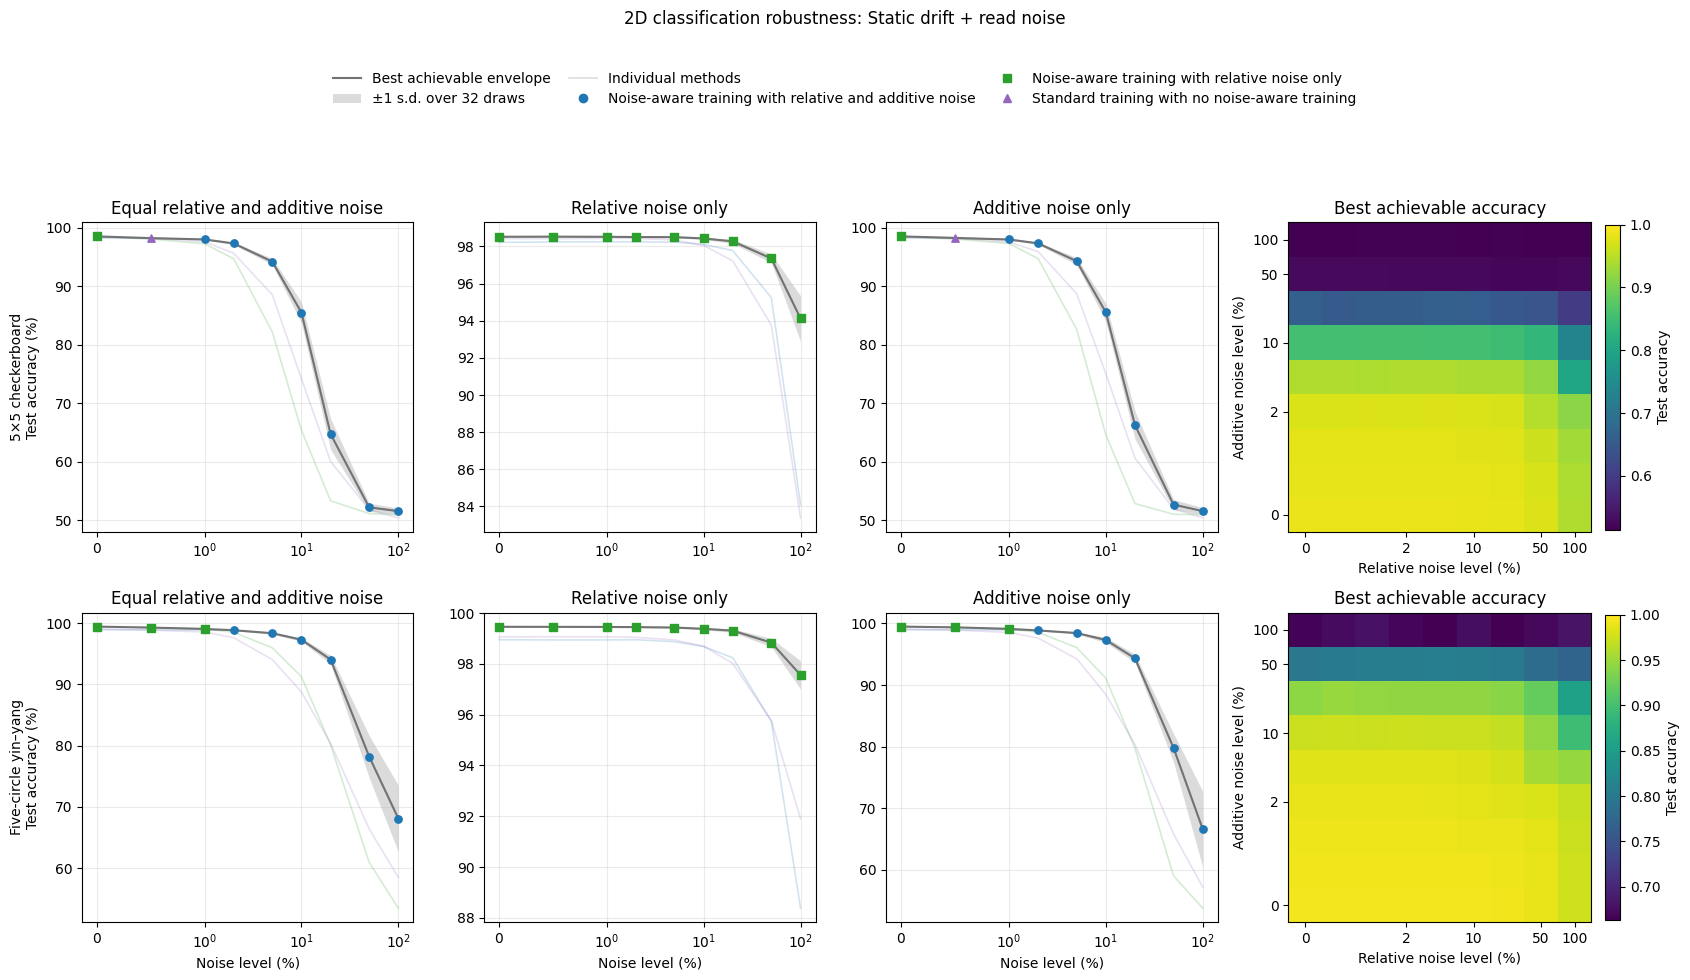

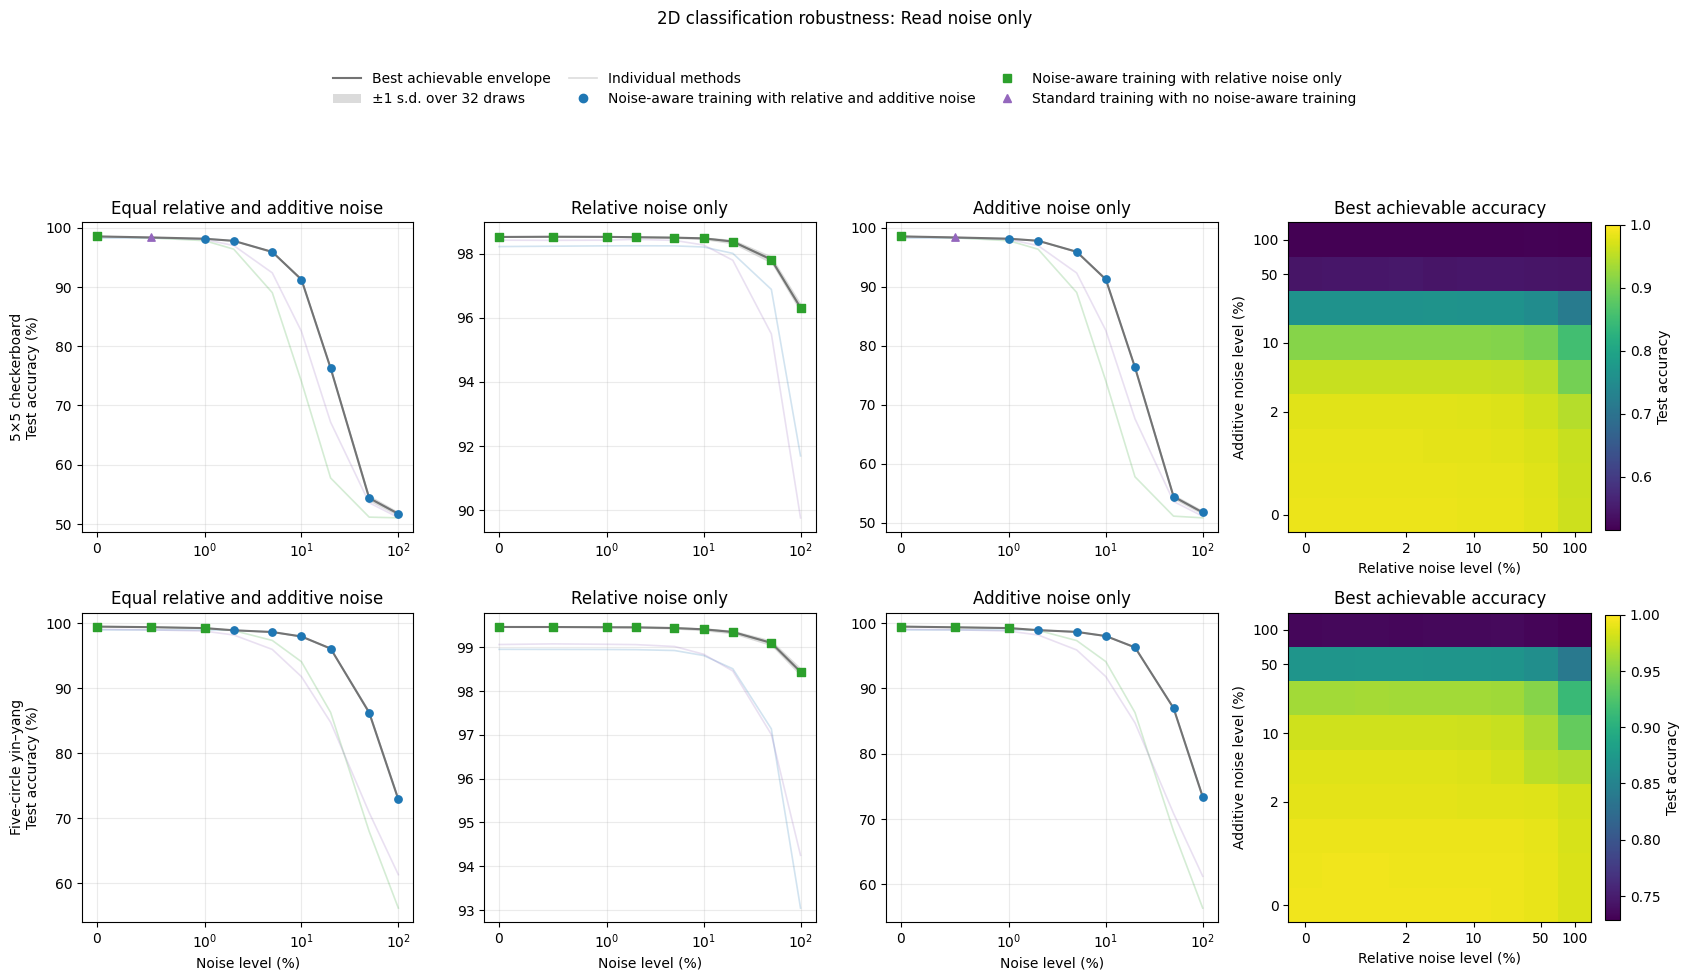

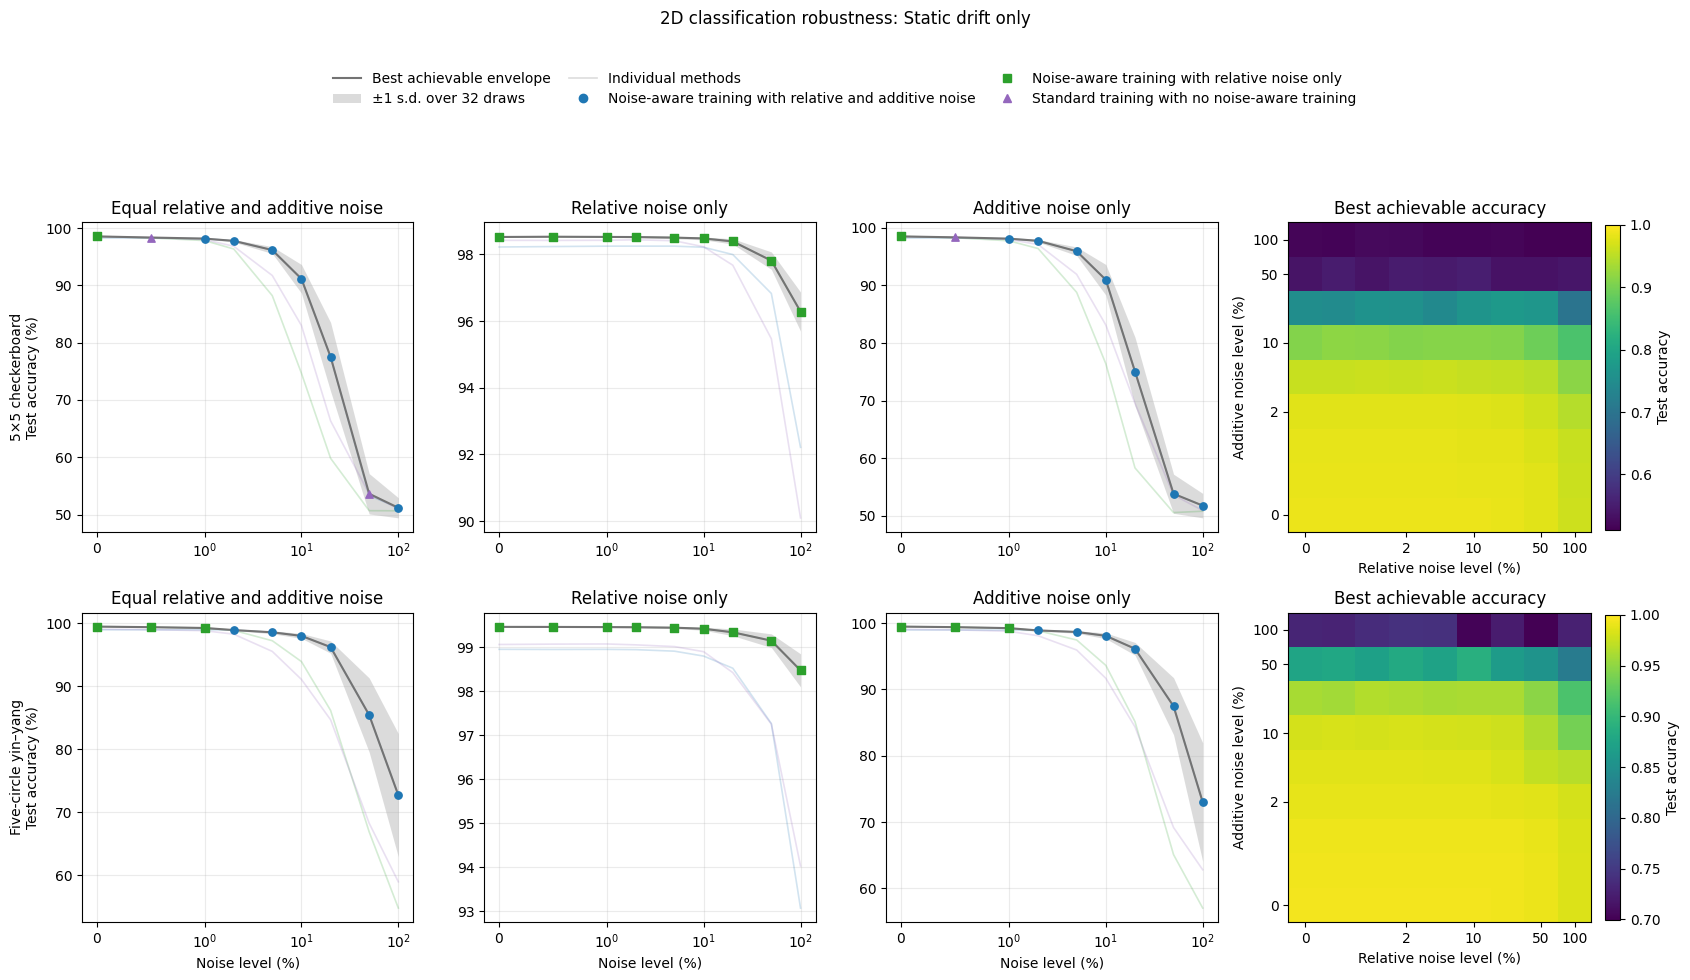

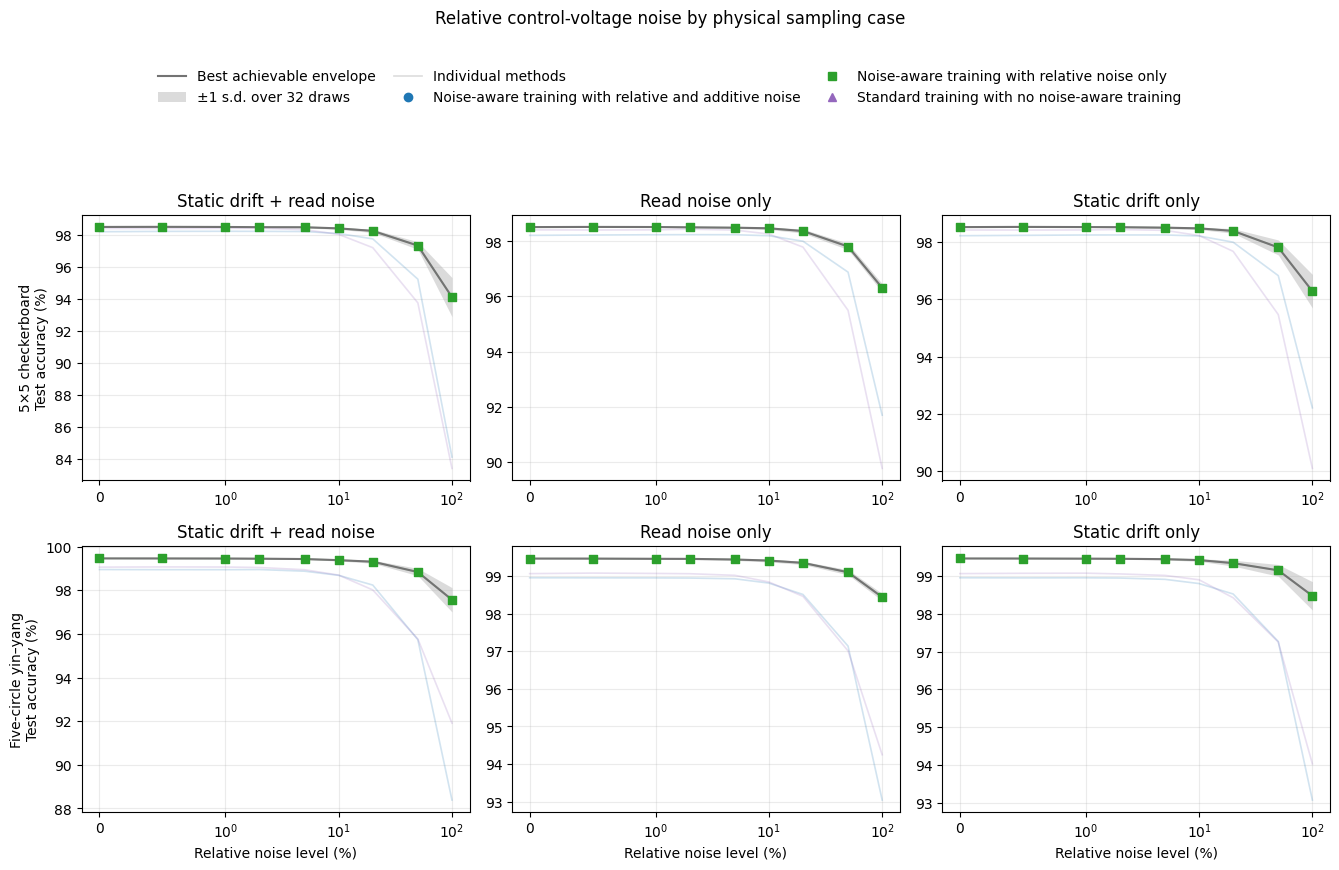

In [11]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

TRAINING_COLOURS = {
    "hybrid_noise_aware": "#1f77b4",
    "relative_noise_aware": "#2ca02c",
    "standard": "#9467bd",
}
TRAINING_MARKERS = {
    "hybrid_noise_aware": "o",
    "relative_noise_aware": "s",
    "standard": "^",
}
SLICE_TITLES = {
    "equal": "Equal relative and additive noise",
    "relative": "Relative noise only",
    "additive": "Additive noise only",
}


def select_slice(frame, slice_name):
    if slice_name == "equal":
        mask = np.isclose(
            frame["relative_percent"], frame["additive_percent"]
        )
        x_column = "relative_percent"
    elif slice_name == "relative":
        mask = np.isclose(frame["additive_percent"], 0.0)
        x_column = "relative_percent"
    elif slice_name == "additive":
        mask = np.isclose(frame["relative_percent"], 0.0)
        x_column = "additive_percent"
    else:
        raise KeyError(slice_name)
    return frame[mask].sort_values(x_column), x_column


def plot_envelope_slice(axis, task, mode, slice_name):
    methods = noise_summary[
        (noise_summary["task"] == task)
        & (noise_summary["mode"] == mode)
    ]
    envelope = noise_envelope[
        (noise_envelope["task"] == task)
        & (noise_envelope["mode"] == mode)
    ]
    for training_configuration in TRAINING_ORDER:
        line, x_column = select_slice(
            methods[methods["training"] == training_configuration],
            slice_name,
        )
        axis.plot(
            line[x_column],
            100.0 * line["test_accuracy_mean"],
            color=TRAINING_COLOURS[training_configuration],
            alpha=0.20,
            linewidth=1.2,
        )

    line, x_column = select_slice(envelope, slice_name)
    x_values = line[x_column].to_numpy(float)
    mean_values = 100.0 * line["envelope_accuracy_mean"].to_numpy(float)
    std_values = 100.0 * line["envelope_accuracy_std"].to_numpy(float)
    axis.fill_between(
        x_values,
        np.clip(mean_values - std_values, 0.0, 100.0),
        np.clip(mean_values + std_values, 0.0, 100.0),
        color="0.75",
        alpha=0.55,
        linewidth=0,
    )
    axis.plot(x_values, mean_values, color="0.45", linewidth=1.5)
    for training_configuration in TRAINING_ORDER:
        points = line[
            line["winner_training"] == training_configuration
        ]
        axis.scatter(
            points[x_column],
            100.0 * points["envelope_accuracy_mean"],
            color=TRAINING_COLOURS[training_configuration],
            marker=TRAINING_MARKERS[training_configuration],
            s=28,
            zorder=4,
        )
    axis.set_xscale("symlog", linthresh=1.0)
    axis.grid(True, alpha=0.25)


def level_tick_indices(levels):
    preferred = {0.0, 2.0, 10.0, 50.0, 100.0}
    indices = [
        index for index, level in enumerate(levels)
        if float(level) in preferred
    ]
    return indices if indices else list(range(len(levels)))


def legend_handles():
    handles = [
        Line2D(
            [0], [0], color="0.45", linewidth=1.5,
            label="Best achievable envelope",
        ),
        Patch(
            facecolor="0.75", alpha=0.55, edgecolor="none",
            label=f"±1 s.d. over {EVAL_DRAWS} draws",
        ),
        Line2D(
            [0], [0], color="0.55", alpha=0.30, linewidth=1.2,
            label="Individual methods",
        ),
    ]
    for training_configuration in TRAINING_ORDER:
        handles.append(Line2D(
            [0], [0],
            color=TRAINING_COLOURS[training_configuration],
            marker=TRAINING_MARKERS[training_configuration],
            linestyle="none",
            markersize=6,
            label=TRAINING_LABELS[training_configuration],
        ))
    return handles


def make_noise_envelope_figure(mode):
    figure, axes = plt.subplots(
        len(TASKS),
        4,
        figsize=(17.0, 4.1 * len(TASKS) + 1.6),
        squeeze=False,
    )
    for row_index, task in enumerate(TASKS):
        for column_index, slice_name in enumerate(
            ("equal", "relative", "additive")
        ):
            axis = axes[row_index, column_index]
            plot_envelope_slice(axis, task, mode, slice_name)
            axis.set_title(SLICE_TITLES[slice_name])
            if column_index == 0:
                axis.set_ylabel(
                    f"{TASK_LABELS[task]}\nTest accuracy (%)"
                )
            if row_index == len(TASKS) - 1:
                axis.set_xlabel("Noise level (%)")

        heatmap_axis = axes[row_index, 3]
        task_grid = noise_envelope[
            (noise_envelope["task"] == task)
            & (noise_envelope["mode"] == mode)
        ]
        grid = (
            task_grid.pivot(
                index="additive_percent",
                columns="relative_percent",
                values="envelope_accuracy_mean",
            )
            .reindex(
                index=ADDITIVE_LEVELS_PERCENT,
                columns=RELATIVE_LEVELS_PERCENT,
            )
            .to_numpy(float)
        )
        image = heatmap_axis.imshow(
            grid,
            origin="lower",
            aspect="auto",
            cmap="viridis",
            vmin=max(0.0, float(np.nanmin(grid))),
            vmax=1.0,
        )
        relative_ticks = level_tick_indices(RELATIVE_LEVELS_PERCENT)
        additive_ticks = level_tick_indices(ADDITIVE_LEVELS_PERCENT)
        heatmap_axis.set_xticks(relative_ticks)
        heatmap_axis.set_xticklabels(
            [f"{RELATIVE_LEVELS_PERCENT[i]:g}" for i in relative_ticks]
        )
        heatmap_axis.set_yticks(additive_ticks)
        heatmap_axis.set_yticklabels(
            [f"{ADDITIVE_LEVELS_PERCENT[i]:g}" for i in additive_ticks]
        )
        heatmap_axis.set_title("Best achievable accuracy")
        heatmap_axis.set_xlabel("Relative noise level (%)")
        heatmap_axis.set_ylabel("Additive noise level (%)")
        colourbar = figure.colorbar(
            image, ax=heatmap_axis, fraction=0.046, pad=0.04
        )
        colourbar.set_label("Test accuracy")

    figure.suptitle(
        f"2D classification robustness: {MODE_LABELS[mode]}",
        y=0.995,
    )
    figure.legend(
        handles=legend_handles(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=3,
        frameon=False,
        columnspacing=1.3,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.85))
    filename = {
        "static_plus_read": "noise_envelope_static_plus_read.png",
        "read_noise": "noise_envelope_read_noise_only.png",
        "static_drift": "noise_envelope_static_drift_only.png",
    }[mode]
    figure.savefig(
        OUTPUT_ROOT / filename,
        dpi=220,
        bbox_inches="tight",
    )
    return figure


ENVELOPE_FIGURES = {}
for mode in EVALUATION_MODES:
    ENVELOPE_FIGURES[mode] = make_noise_envelope_figure(mode)
    plt.show()


def make_requested_mode_overview():
    figure, axes = plt.subplots(
        len(TASKS),
        len(EVALUATION_MODES),
        figsize=(13.5, 3.6 * len(TASKS) + 1.5),
        squeeze=False,
    )
    for row_index, task in enumerate(TASKS):
        for column_index, mode in enumerate(EVALUATION_MODES):
            axis = axes[row_index, column_index]
            plot_envelope_slice(axis, task, mode, "relative")
            axis.set_title(MODE_LABELS[mode])
            if column_index == 0:
                axis.set_ylabel(
                    f"{TASK_LABELS[task]}\nTest accuracy (%)"
                )
            if row_index == len(TASKS) - 1:
                axis.set_xlabel("Relative noise level (%)")

    figure.suptitle(
        "Relative control-voltage noise by physical sampling case",
        y=0.995,
    )
    figure.legend(
        handles=legend_handles(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=3,
        frameon=False,
        columnspacing=1.3,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.84))
    figure.savefig(
        OUTPUT_ROOT
        / "accuracy_under_relative_noise_requested_mode_order.png",
        dpi=220,
        bbox_inches="tight",
    )
    return figure


REQUESTED_MODE_FIGURE = make_requested_mode_overview()
plt.show()


## Output files

- best_*.pt: standard, relative-noise-aware and relative+additive-noise-aware checkpoints;
- noise_grid_draws.csv: every raw evaluation draw;
- noise_grid_summary.csv: mean accuracy, standard deviation, draw count and mean saturation fraction;
- noise_grid_best_achievable_envelope.csv: the winning method and best mean accuracy at every grid point;
- noise_envelope_static_plus_read.png: slices and 2D heatmaps for combined static drift and read noise;
- noise_envelope_read_noise_only.png: equivalent read-only outputs;
- noise_envelope_static_drift_only.png: equivalent static-only outputs;
- accuracy_under_relative_noise_requested_mode_order.png: the requested left-to-right static+read, read-only, static-only comparison.
